In [1]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from pathlib import Path
import numpy as np
import re
import pandas as pd

In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

with open(
    "FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_50Agree.txt",
    encoding="latin-1"
) as sentences_file:
    raw_sentences = sentences_file.read()

sentences_list_with_sentiments = raw_sentences.split("\n")[:-1]

sentences_list = []
y = []
sentiment_dictionary = {"negative": 2, "neutral": 0, "positive": 1}

for sentence in sentences_list_with_sentiments:
    text, sentiment = sentence.rsplit('@', 1)
    sentences_list.append(text)
    y.append(sentiment_dictionary[sentiment])
y = np.array(y)

def preprocess_sentences(sentences_list):
    sentences_list_all_lower = [sentence.lower() for sentence in sentences_list]

    noise_characters_dict = {"%": "", ",":"", "(":"", ")":"", ":":"", "n't":" not", "'s":"", "€":"", "$":"", "``":"", "''":"", "...":"", "`":"", "'":"" ,"  ":" "}
    sentences_list_denoised = sentences_list_all_lower
    for noise_character, replace_character in noise_characters_dict.items():
        sentences_list_denoised = [sentence.replace(noise_character, replace_character) for sentence in sentences_list_denoised]

    nltk_stop_words = set(stopwords.words('english'))
    not_stop_words = {"above", "after", "against", "before", "below", "between", "down", "from", "no", "not", "nor", "off", "only", "over", "same", "to", "under", "up"}
    additional_stop_words = {"bln", "mln", "pct", "percent"}
    stop_words = (nltk_stop_words - not_stop_words).union(additional_stop_words)
    # stop_words = (nltk_stop_words - not_stop_words)
    sentences_list_without_stop_words = []
    for sentence in sentences_list_denoised:
        words_list = word_tokenize(sentence)
        sentence_without_stop_words = " ".join([word for word in words_list if word not in stop_words])
        sentences_list_without_stop_words.append(sentence_without_stop_words)
    
    lemmatizer = WordNetLemmatizer()
    sentences_list_lemmatized = []
    for sentence in sentences_list_without_stop_words:
        words_list = word_tokenize(sentence)
        sentence_lemmatized = " ".join([lemmatizer.lemmatize(word) for word in words_list])
        sentences_list_lemmatized.append(sentence_lemmatized)

    sentences_list_only_ascii = sentences_list_lemmatized
    sentences_list_only_ascii = [re.sub(r'[^.a-zA-Z0-9\s<>\-]', '', sentence) for sentence in sentences_list_only_ascii]

    sentences_list_without_numbers = []
    for sentence in sentences_list_only_ascii:
        sentence_without_numbers = re.sub(r'\b\d+\s*(?:[\.,]\s*\d+)?\b', ' <NUM> ', sentence).replace(".", "").replace("-", " ").replace("  ", " ")
        sentences_list_without_numbers.append(sentence_without_numbers)
    
    return sentences_list_all_lower, sentences_list_denoised, sentences_list_without_stop_words, sentences_list_lemmatized, sentences_list_only_ascii, sentences_list_without_numbers

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/theohagen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/theohagen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
_, _, _, _, _, X = preprocess_sentences(sentences_list)

### Some more conditionals

In [4]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

### Creating Train/Val/Test Splits:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=43,
    shuffle=True,
    stratify=y
)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

bow_vectorizer = CountVectorizer()

X_train_bow_t = torch.tensor(bow_vectorizer.fit_transform(X_train).toarray(), dtype=torch.float32)
X_test_bow_t = torch.tensor(bow_vectorizer.transform(X_test).toarray(), dtype=torch.float32)

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf_t = torch.tensor(tfidf_vectorizer.fit_transform(X_train).toarray(), dtype=torch.float32)
X_test_tfidf_t = torch.tensor(tfidf_vectorizer.transform(X_test).toarray(), dtype=torch.float32)

print(X_train_bow_t.shape, X_test_bow_t.shape)
print(X_train_tfidf_t.shape, X_test_tfidf_t.shape)
print(y_train.shape, y_test.shape)

torch.Size([3876, 7635]) torch.Size([970, 7635])
torch.Size([3876, 7635]) torch.Size([970, 7635])
(3876,) (970,)


### Feed-Forward Neural Network

In [6]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [7]:
def run_model(train_loader, test_loader, epochs=5, lr=0.001, num_classes = 3, target_names=["neutral", "positive", "negative"]):  
    input_dim = train_loader.dataset.tensors[0].shape[1]

    model = FeedForwardNN(
        input_dim=input_dim,
        hidden_dim=32,
        num_classes=num_classes
    )

    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        # ---------- Training ----------
        model.train()
        total_train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            logits = model(X_batch)
            batch_loss = loss(logits, y_batch)

            batch_loss.backward()
            optimizer.step()

            total_train_loss += batch_loss.item() * X_batch.size(0)

        avg_train_loss = total_train_loss / len(train_loader.dataset)

        # ---------- Validation ----------
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                logits = model(X_batch)
                batch_loss = loss(logits, y_batch)

                total_val_loss += batch_loss.item() * X_batch.size(0)

                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        avg_val_loss = total_val_loss / len(test_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average="macro")

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Test Loss: {avg_val_loss:.4f} | "
            f"Test Acc: {val_acc:.4f} | "
            f"Test Macro-F1: {val_f1:.4f}"
        )

    # ---------- Report ----------
    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        labels=list(range(num_classes)),
        target_names=target_names,
        zero_division=0
    ))

    return all_labels, all_preds

### Bag of Words

In [8]:
train_dataset = TensorDataset(X_train_bow_t, y_train_t)
test_dataset = TensorDataset(X_test_bow_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

bow_true, bow_pred = run_model(train_loader, test_loader)

Epoch 1/5 | Train Loss: 0.9380 | Test Loss: 0.7766 | Test Acc: 0.6866 | Test Macro-F1: 0.4808
Epoch 2/5 | Train Loss: 0.6557 | Test Loss: 0.6443 | Test Acc: 0.7402 | Test Macro-F1: 0.6136
Epoch 3/5 | Train Loss: 0.4695 | Test Loss: 0.5876 | Test Acc: 0.7567 | Test Macro-F1: 0.6646
Epoch 4/5 | Train Loss: 0.3381 | Test Loss: 0.5693 | Test Acc: 0.7670 | Test Macro-F1: 0.6915
Epoch 5/5 | Train Loss: 0.2529 | Test Loss: 0.5721 | Test Acc: 0.7629 | Test Macro-F1: 0.6927

Classification Report:
              precision    recall  f1-score   support

     neutral       0.78      0.90      0.84       576
    positive       0.73      0.58      0.65       273
    negative       0.68      0.52      0.59       121

    accuracy                           0.76       970
   macro avg       0.73      0.67      0.69       970
weighted avg       0.76      0.76      0.75       970



### Tfidf

In [9]:
train_dataset = TensorDataset(X_train_tfidf_t, y_train_t)
test_dataset = TensorDataset(X_test_tfidf_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

tfidf_true, tfidf_pred = run_model(train_loader, test_loader, epochs=8)

Epoch 1/8 | Train Loss: 1.0132 | Test Loss: 0.8809 | Test Acc: 0.6216 | Test Macro-F1: 0.3141
Epoch 2/8 | Train Loss: 0.8032 | Test Loss: 0.7567 | Test Acc: 0.6742 | Test Macro-F1: 0.4101
Epoch 3/8 | Train Loss: 0.6658 | Test Loss: 0.6870 | Test Acc: 0.7103 | Test Macro-F1: 0.5177
Epoch 4/8 | Train Loss: 0.5493 | Test Loss: 0.6376 | Test Acc: 0.7381 | Test Macro-F1: 0.6037
Epoch 5/8 | Train Loss: 0.4514 | Test Loss: 0.6074 | Test Acc: 0.7485 | Test Macro-F1: 0.6441
Epoch 6/8 | Train Loss: 0.3627 | Test Loss: 0.5894 | Test Acc: 0.7474 | Test Macro-F1: 0.6636
Epoch 7/8 | Train Loss: 0.3081 | Test Loss: 0.5825 | Test Acc: 0.7557 | Test Macro-F1: 0.6809
Epoch 8/8 | Train Loss: 0.2606 | Test Loss: 0.5803 | Test Acc: 0.7639 | Test Macro-F1: 0.7003

Classification Report:
              precision    recall  f1-score   support

     neutral       0.79      0.89      0.84       576
    positive       0.70      0.61      0.65       273
    negative       0.77      0.51      0.61       121

    ac

### Confusion Matrix

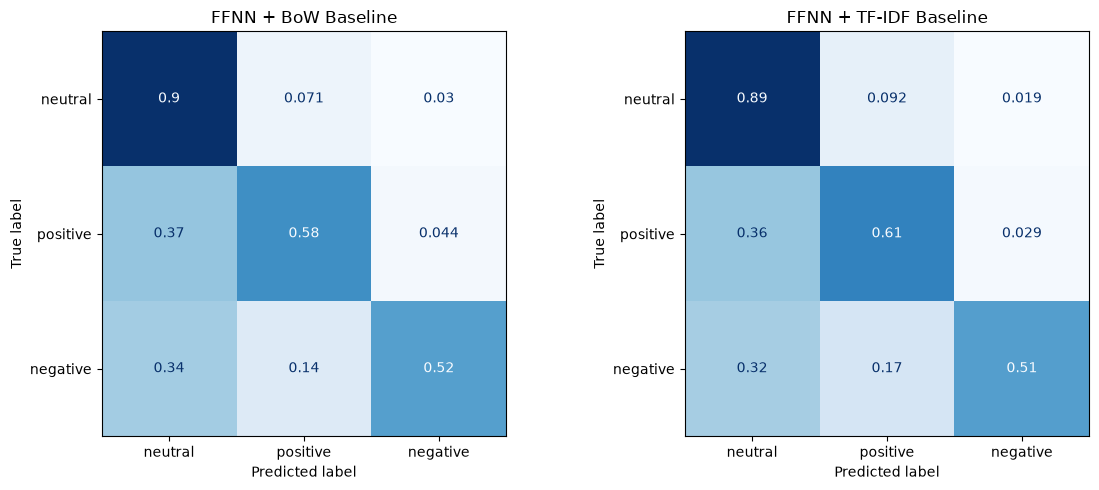

In [21]:
class_names = ["neutral", "positive", "negative"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    bow_true,
    bow_pred,
    labels=[0, 1, 2],
    display_labels=class_names,
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
    normalize='true'
)

axes[0].set_title("FFNN + BoW Baseline")

ConfusionMatrixDisplay.from_predictions(
    tfidf_true,
    tfidf_pred,
    labels=[0, 1, 2],
    display_labels=class_names,
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
    normalize='true'
)

axes[1].set_title("FFNN + TF-IDF Baseline")

plt.tight_layout()
plt.show()

### Oversampling

In [11]:
df_train = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

max_class_size = df_train["label"].value_counts().max()
oversampled = []

for label in df_train["label"].unique():
    class_df = df_train[df_train["label"] == label]

    label_oversample = resample(
        class_df,
        replace=True,
        n_samples=max_class_size,
        random_state=43
    )

    oversampled.append(label_oversample)

df_oversampled = pd.concat(oversampled)
df_oversampled = df_oversampled.sample(frac=1, random_state=43).reset_index(drop=True)

df_oversampled["label"].value_counts()

label
2    2303
0    2303
1    2303
Name: count, dtype: int64

### FFNN + BoW + Oversampling

In [12]:
X_train_bow_over_t = torch.tensor(
    bow_vectorizer.transform(df_oversampled["text"]).toarray(),
    dtype=torch.float32
)

y_train_over_t = torch.tensor(
    df_oversampled["label"].values,
    dtype=torch.long
)

train_dataset = TensorDataset(X_train_bow_over_t, y_train_over_t)
test_dataset = TensorDataset(X_test_bow_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("FFNN + BoW + Oversampling")
_, _ = run_model(train_loader, test_loader, epochs=5, lr=0.0005)

FFNN + BoW + Oversampling
Epoch 1/5 | Train Loss: 0.9539 | Test Loss: 0.8808 | Test Acc: 0.7052 | Test Macro-F1: 0.6416
Epoch 2/5 | Train Loss: 0.5911 | Test Loss: 0.6858 | Test Acc: 0.7557 | Test Macro-F1: 0.7010
Epoch 3/5 | Train Loss: 0.3683 | Test Loss: 0.6125 | Test Acc: 0.7557 | Test Macro-F1: 0.7069
Epoch 4/5 | Train Loss: 0.2558 | Test Loss: 0.5835 | Test Acc: 0.7557 | Test Macro-F1: 0.7100
Epoch 5/5 | Train Loss: 0.1854 | Test Loss: 0.5819 | Test Acc: 0.7619 | Test Macro-F1: 0.7175

Classification Report:
              precision    recall  f1-score   support

     neutral       0.83      0.82      0.82       576
    positive       0.68      0.68      0.68       273
    negative       0.63      0.66      0.65       121

    accuracy                           0.76       970
   macro avg       0.71      0.72      0.72       970
weighted avg       0.76      0.76      0.76       970



### FFNN + TFIDF + Oversampling

In [13]:
X_train_tfidf_over_t = torch.tensor(
    tfidf_vectorizer.transform(df_oversampled["text"]).toarray(),
    dtype=torch.float32
)

y_train_over_t = torch.tensor(
    df_oversampled["label"].values,
    dtype=torch.long
)

train_dataset = TensorDataset(X_train_tfidf_over_t, y_train_over_t)
test_dataset = TensorDataset(X_test_tfidf_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("FFNN + TF-IDF + Oversampling")
_, _ = run_model(train_loader, test_loader, epochs=5)

FFNN + TF-IDF + Oversampling
Epoch 1/5 | Train Loss: 0.9704 | Test Loss: 0.8836 | Test Acc: 0.6928 | Test Macro-F1: 0.6110
Epoch 2/5 | Train Loss: 0.5681 | Test Loss: 0.6638 | Test Acc: 0.7392 | Test Macro-F1: 0.6890
Epoch 3/5 | Train Loss: 0.3341 | Test Loss: 0.6010 | Test Acc: 0.7464 | Test Macro-F1: 0.7026
Epoch 4/5 | Train Loss: 0.2248 | Test Loss: 0.5702 | Test Acc: 0.7629 | Test Macro-F1: 0.7169
Epoch 5/5 | Train Loss: 0.1625 | Test Loss: 0.5680 | Test Acc: 0.7546 | Test Macro-F1: 0.7063

Classification Report:
              precision    recall  f1-score   support

     neutral       0.83      0.82      0.82       576
    positive       0.67      0.66      0.66       273
    negative       0.62      0.64      0.63       121

    accuracy                           0.75       970
   macro avg       0.70      0.71      0.71       970
weighted avg       0.76      0.75      0.75       970



### Undersampling

In [14]:
min_class_size = df_train["label"].value_counts().min()
undersampled = []

for label in df_train["label"].unique():
    class_df = df_train[df_train["label"] == label]

    label_undersample = resample(
        class_df,
        replace=False,
        n_samples=min_class_size,
        random_state=43
    )

    undersampled.append(label_undersample)

df_undersampled = pd.concat(undersampled)
df_undersampled = df_undersampled.sample(frac=1, random_state=43).reset_index(drop=True)

df_undersampled["label"].value_counts()

label
2    483
0    483
1    483
Name: count, dtype: int64

### FFNN + BoW + Undersampling

In [15]:
X_train_bow_under_t = torch.tensor(
    bow_vectorizer.transform(df_undersampled["text"]).toarray(),
    dtype=torch.float32
)

y_train_under_t = torch.tensor(
    df_undersampled["label"].values,
    dtype=torch.long
)

train_dataset = TensorDataset(X_train_bow_under_t, y_train_under_t)
test_dataset = TensorDataset(X_test_bow_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("FFNN + BoW + Undersampling")
_, _ = run_model(train_loader, test_loader, epochs=7)

FFNN + BoW + Undersampling
Epoch 1/7 | Train Loss: 1.0726 | Test Loss: 1.0296 | Test Acc: 0.6299 | Test Macro-F1: 0.5563
Epoch 2/7 | Train Loss: 0.9351 | Test Loss: 0.9328 | Test Acc: 0.6175 | Test Macro-F1: 0.5741
Epoch 3/7 | Train Loss: 0.7403 | Test Loss: 0.8493 | Test Acc: 0.6536 | Test Macro-F1: 0.5984
Epoch 4/7 | Train Loss: 0.5569 | Test Loss: 0.7732 | Test Acc: 0.7062 | Test Macro-F1: 0.6639
Epoch 5/7 | Train Loss: 0.4185 | Test Loss: 0.7213 | Test Acc: 0.7072 | Test Macro-F1: 0.6781
Epoch 6/7 | Train Loss: 0.3184 | Test Loss: 0.6887 | Test Acc: 0.7072 | Test Macro-F1: 0.6739
Epoch 7/7 | Train Loss: 0.2564 | Test Loss: 0.6833 | Test Acc: 0.7186 | Test Macro-F1: 0.6900

Classification Report:
              precision    recall  f1-score   support

     neutral       0.85      0.72      0.78       576
    positive       0.58      0.71      0.64       273
    negative       0.59      0.72      0.65       121

    accuracy                           0.72       970
   macro avg       

### FFNN + Tfidf + Undersampling

In [16]:
X_train_tfidf_under_t = torch.tensor(
    tfidf_vectorizer.transform(df_undersampled["text"]).toarray(),
    dtype=torch.float32
)

y_train_under_t = torch.tensor(
    df_undersampled["label"].values,
    dtype=torch.long
)

train_dataset = TensorDataset(X_train_tfidf_under_t, y_train_under_t)
test_dataset = TensorDataset(X_test_tfidf_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("FFNN + Tfidf + Undersampling")
_, _ = run_model(train_loader, test_loader, epochs=16)

FFNN + Tfidf + Undersampling
Epoch 1/16 | Train Loss: 1.0921 | Test Loss: 1.1015 | Test Acc: 0.1258 | Test Macro-F1: 0.0752
Epoch 2/16 | Train Loss: 1.0492 | Test Loss: 1.0745 | Test Acc: 0.4856 | Test Macro-F1: 0.4540
Epoch 3/16 | Train Loss: 0.9658 | Test Loss: 1.0284 | Test Acc: 0.5701 | Test Macro-F1: 0.5338
Epoch 4/16 | Train Loss: 0.8551 | Test Loss: 0.9638 | Test Acc: 0.6113 | Test Macro-F1: 0.5773
Epoch 5/16 | Train Loss: 0.7374 | Test Loss: 0.9065 | Test Acc: 0.6351 | Test Macro-F1: 0.5931
Epoch 6/16 | Train Loss: 0.6244 | Test Loss: 0.8505 | Test Acc: 0.6588 | Test Macro-F1: 0.6202
Epoch 7/16 | Train Loss: 0.5243 | Test Loss: 0.7997 | Test Acc: 0.6794 | Test Macro-F1: 0.6449
Epoch 8/16 | Train Loss: 0.4344 | Test Loss: 0.7721 | Test Acc: 0.6918 | Test Macro-F1: 0.6544
Epoch 9/16 | Train Loss: 0.3647 | Test Loss: 0.7547 | Test Acc: 0.6866 | Test Macro-F1: 0.6612
Epoch 10/16 | Train Loss: 0.3186 | Test Loss: 0.7327 | Test Acc: 0.6948 | Test Macro-F1: 0.6656
Epoch 11/16 | Train 

### Binary FFNN with BoW

In [17]:
df_train_binary = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

df_test_binary = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

df_train_binary = df_train_binary[df_train_binary["label"] != 0].copy()
df_test_binary = df_test_binary[df_test_binary["label"] != 0].copy()

binary_mapping = {
    2: 0,
    1: 1
}

df_train_binary["label"] = df_train_binary["label"].map(binary_mapping)
df_test_binary["label"] = df_test_binary["label"].map(binary_mapping)

print("Binary train distribution:")
print(df_train_binary["label"].value_counts())

print("\nBinary test distribution:")
print(df_test_binary["label"].value_counts())

Binary train distribution:
label
1    1090
0     483
Name: count, dtype: int64

Binary test distribution:
label
1    273
0    121
Name: count, dtype: int64


In [18]:
bow_vectorizer_binary = CountVectorizer()

X_train_bow_binary = bow_vectorizer_binary.fit_transform(df_train_binary["text"])
X_test_bow_binary = bow_vectorizer_binary.transform(df_test_binary["text"])

X_train_bow_binary_t = torch.tensor(
    X_train_bow_binary.toarray(),
    dtype=torch.float32
)

X_test_bow_binary_t = torch.tensor(
    X_test_bow_binary.toarray(),
    dtype=torch.float32
)

y_train_binary_t = torch.tensor(
    df_train_binary["label"].values,
    dtype=torch.long
)

y_test_binary_t = torch.tensor(
    df_test_binary["label"].values,
    dtype=torch.long
)

train_dataset_binary_bow = TensorDataset(
    X_train_bow_binary_t,
    y_train_binary_t
)

test_dataset_binary_bow = TensorDataset(
    X_test_bow_binary_t,
    y_test_binary_t
)

train_loader_binary_bow = DataLoader(
    train_dataset_binary_bow,
    batch_size=32,
    shuffle=True
)

test_loader_binary_bow = DataLoader(
    test_dataset_binary_bow,
    batch_size=32,
    shuffle=False
)

In [19]:
_, _ = run_model(
    train_loader_binary_bow,
    test_loader_binary_bow,
    epochs=7,
    num_classes=2,
    target_names=["negative", "positive"]
)

Epoch 1/7 | Train Loss: 0.6370 | Test Loss: 0.5746 | Test Acc: 0.7005 | Test Macro-F1: 0.4353
Epoch 2/7 | Train Loss: 0.4833 | Test Loss: 0.4595 | Test Acc: 0.7893 | Test Macro-F1: 0.6847
Epoch 3/7 | Train Loss: 0.3241 | Test Loss: 0.3815 | Test Acc: 0.8426 | Test Macro-F1: 0.7987
Epoch 4/7 | Train Loss: 0.2118 | Test Loss: 0.3441 | Test Acc: 0.8579 | Test Macro-F1: 0.8193
Epoch 5/7 | Train Loss: 0.1466 | Test Loss: 0.3254 | Test Acc: 0.8604 | Test Macro-F1: 0.8231
Epoch 6/7 | Train Loss: 0.1086 | Test Loss: 0.3232 | Test Acc: 0.8655 | Test Macro-F1: 0.8305
Epoch 7/7 | Train Loss: 0.0851 | Test Loss: 0.3218 | Test Acc: 0.8604 | Test Macro-F1: 0.8251

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.67      0.75       121
    positive       0.87      0.95      0.90       273

    accuracy                           0.86       394
   macro avg       0.85      0.81      0.83       394
weighted avg       0.86      0.86      0.86   